In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv("outputs/benchmark_collected.csv")
df.head()

,scenario,env_name,batch_size,library,seed,n_iterations,mean_iter_time_ms,std_iter_time_ms,total_time_s,throughput_iters_per_sec,...,phase_backward_mean_ms,phase_backward_total_s,phase_loss_mean_ms,phase_loss_total_s,phase_optimizer_mean_ms,phase_optimizer_total_s,phase_sample_mean_ms,phase_sample_total_s,phase_total_mean_ms,phase_total_total_s
0,tb_bitseq_medium_bs128,bitseq,128,gfnx,0,100,2.019944,0.121081,0.256768,389.456423,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.387343,0.138734
1,tb_bitseq_medium_bs128,bitseq,128,gfnx,1,100,2.055865,0.219060,0.261245,382.782373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.426578,0.142658
2,tb_bitseq_medium_bs128,bitseq,128,gfnx,2,100,2.331183,0.485898,0.288374,346.772246,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.416472,0.141647
3,tb_bitseq_medium_bs128,bitseq,128,torchgfn,0,100,18.983769,0.848192,1.900399,52.620537,...,2.643658,0.396549,3.908240,0.586236,0.510830,0.076624,11.895047,1.784257,NaN,NaN
4,tb_bitseq_medium_bs128,bitseq,128,torchgfn,1,100,18.696497,0.552931,1.871652,53.428748,...,2.647821,0.397173,3.824017,0.573603,0.476486,0.071473,11.754986,1.763248,NaN,NaN


In [ ]:
import re

# Derive a config label from scenario (strip tb_ prefix and _bs* suffix)
df["config"] = df["scenario"].apply(lambda s: re.sub(r"_bs\d+$", "", re.sub(r"^tb_", "", s)))

# Aggregate over seeds: mean and std of mean_iter_time_ms
agg = df.groupby(["config", "batch_size", "library"])["mean_iter_time_ms"].agg(["mean", "std"]).reset_index()
agg.columns = ["config", "batch_size", "library", "iter_time_mean", "iter_time_std"]
print("Configs:", sorted(agg["config"].unique()))
agg

Configs: ['bitseq_medium', 'bitseq_small', 'box_2d', 'box_2d_uniform_pb', 'hypergrid_large', 'hypergrid_medium', 'hypergrid_small', 'ising_10x10', 'ising_6x6']


,config,batch_size,library,iter_time_mean,iter_time_std
0,bitseq_medium,32,gfnx,2.115646,0.148762
1,bitseq_medium,32,torchgfn,16.165851,0.028436
2,bitseq_medium,128,gfnx,2.135664,0.170274
3,bitseq_medium,128,torchgfn,18.881613,0.160602
4,bitseq_medium,512,gfnx,2.281687,0.032764
...,...,...,...,...,...
63,ising_6x6,128,gfnx,4.795834,0.598603
64,ising_6x6,128,torchgfn,93.587627,0.880150
65,ising_6x6,512,gflownet,14538.770519,37.727941
66,ising_6x6,512,gfnx,6.877076,0.170533


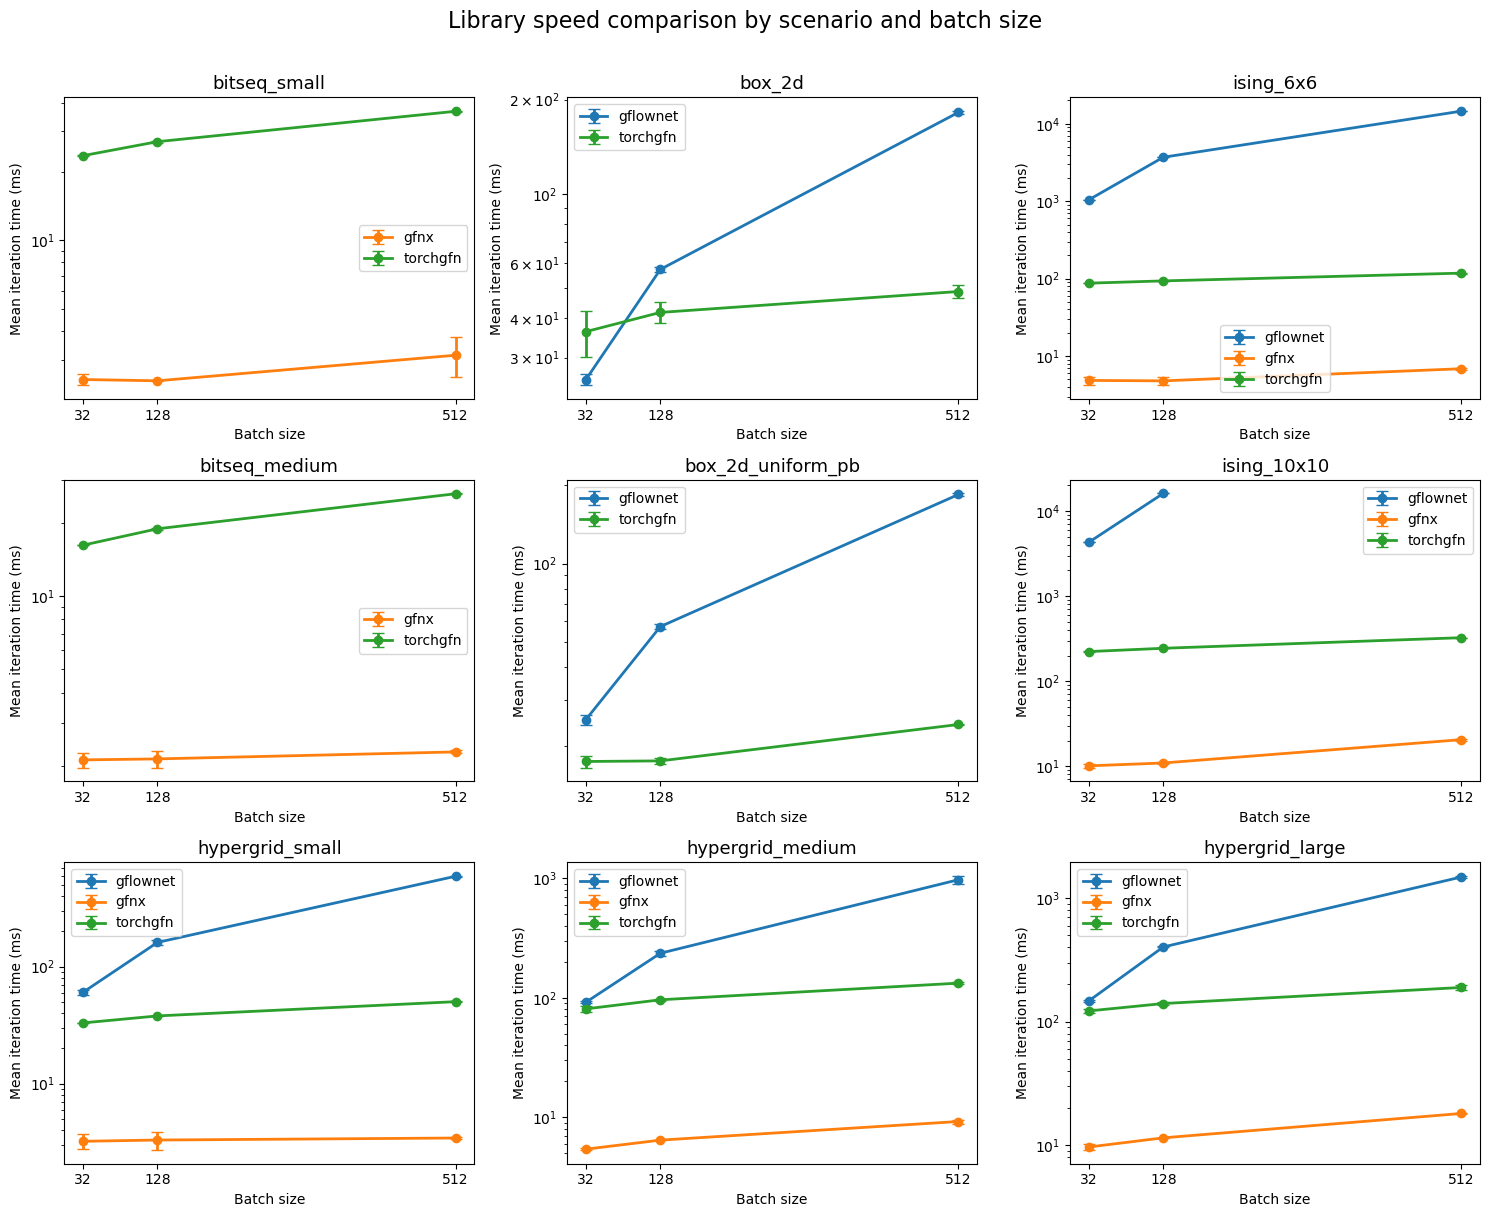

In [ ]:
configs = sorted(agg["config"].unique())
batch_sizes = sorted(agg["batch_size"].unique())
libraries = sorted(agg["library"].unique())
colors = {lib: c for lib, c in zip(libraries, plt.cm.tab10.colors)}

configs = [
    "bitseq_small", "box_2d", "ising_6x6",
    "bitseq_medium", "box_2d_uniform_pb", "ising_10x10",
    "hypergrid_small", "hypergrid_medium", "hypergrid_large",
]

n_cols = 3
n_rows = -(-len(configs) // n_cols)  # ceil division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=False)
axes = axes.flatten()

for ax, cfg in zip(axes, configs):
    cfg_data = agg[agg["config"] == cfg]

    for lib in libraries:
        lib_data = cfg_data[cfg_data["library"] == lib].sort_values("batch_size")
        if lib_data.empty:
            continue
        ax.errorbar(lib_data["batch_size"], lib_data["iter_time_mean"],
                     yerr=lib_data["iter_time_std"], label=lib,
                     color=colors[lib], marker="o", capsize=4, linewidth=2)

    ax.set_yscale("log")
    ax.set_xticks(batch_sizes)
    ax.set_xticklabels(batch_sizes)
    ax.set_title(cfg, fontsize=13)
    ax.set_xlabel("Batch size")
    ax.set_ylabel("Mean iteration time (ms)")
    ax.legend()

# Hide unused subplots
for ax in axes[len(configs):]:
    ax.set_visible(False)

fig.suptitle("Library speed comparison by scenario and batch size", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
configs = [
    "bitseq_small", "box_2d", "ising_6x6",
    "bitseq_medium", "box_2d_uniform_pb", "ising_10x10",
    "hypergrid_small", "hypergrid_medium", "hypergrid_large",
]

['bitseq_medium',
 'bitseq_small',
 'box_2d',
 'box_2d_uniform_pb',
 'hypergrid_large',
 'hypergrid_medium',
 'hypergrid_small',
 'ising_10x10',
 'ising_6x6']

In [ ]:
import seaborn as sns

lib_order = ["gflownet", "torchgfn", "gfnx"]

configs = [
    "bitseq_small",
    "bitseq_medium",
    "box_2d",
    "box_2d_uniform_pb",
    "ising_6x6",
    "ising_10x10",
    "hypergrid_small",
    "hypergrid_medium",
    "hypergrid_large",
]

# Pivot: rows = (config, library), columns = batch_size
heat_mean = agg.pivot_table(index=["config", "library"], columns="batch_size", values="iter_time_mean")
heat_std = agg.pivot_table(index=["config", "library"], columns="batch_size", values="iter_time_std")

# Reorder rows: configs in the custom order, libraries in lib_order (skip missing)
idx = pd.MultiIndex.from_tuples(
    [(cfg, lib) for cfg in configs for lib in lib_order if (cfg, lib) in heat_mean.index],
    names=["config", "library"]
)
heat_mean = heat_mean.reindex(idx)
heat_std = heat_std.reindex(idx)

# Get torchgfn times for speedup calculation
torchgfn_mean = heat_mean.xs("torchgfn", level="library")

# Build annotations with speedup for non-torchgfn libraries
def fmt_val(m, s):
    if pd.isna(m):
        return ""
    if m < 100:
        return f"{m:.1f}\n(±{s:.1f})"
    return f"{m:.0f}\n(±{s:.0f})"

def fmt_speedup(m, ref):
    if pd.isna(m) or pd.isna(ref):
        return ""
    ratio = ref / m
    if ratio >= 1:
        return f"{ratio:.1f}x faster"
    else:
        return f"{1/ratio:.1f}x slower"

annot_df = heat_mean.copy().astype(object)
for col in annot_df.columns:
    for cfg, lib in annot_df.index:
        m = heat_mean.loc[(cfg, lib), col]
        s = heat_std.loc[(cfg, lib), col]
        base = fmt_val(m, s)
        if lib == "torchgfn":
            # Add blank line to vertically center the 2-line text
            annot_df.loc[(cfg, lib), col] = f"\n{base}\n"
        else:
            ref = torchgfn_mean.loc[cfg, col] if cfg in torchgfn_mean.index else np.nan
            speedup = fmt_speedup(m, ref)
            annot_df.loc[(cfg, lib), col] = f"{base}\n{speedup}" if base else ""

# Build y-axis labels with aligned columns using monospace padding
max_cfg_len = max(len(cfg) for cfg in configs)
max_lib_len = max(len(lib) for lib in lib_order)
ylabels = [f"{cfg:<{max_cfg_len}}  {lib:>{max_lib_len}}" for cfg, lib in heat_mean.index]

fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(
    np.log10(heat_mean),
    annot=annot_df,
    fmt="",
    cmap="cividis",
    linewidths=0.5,
    cbar_kws={"label": "log10(ms)", "shrink": 0.5},
    annot_kws={"fontsize": 7.5},
    ax=ax,
)

# Draw thicker horizontal lines between scenario groups
prev_cfg = None
for i, (cfg, lib) in enumerate(heat_mean.index):
    if prev_cfg is not None and cfg != prev_cfg:
        ax.axhline(y=i, color="orange", linewidth=1)
    prev_cfg = cfg

ax.set_yticklabels(ylabels, rotation=0, fontsize=9, fontfamily="monospace")
ax.set_xlabel("Batch size")
ax.set_ylabel("")
ax.set_title("Iteration time (ms) mean $\pm$ std - log-scale color, raw annotations", fontsize=11)
plt.tight_layout()
fig.savefig("outputs/benchmark_heatmap.svg", bbox_inches="tight")
plt.show()

In [ ]:
configs = [
    "bitseq_small",
    "bitseq_medium",
    "box_2d",
    "box_2d_uniform_pb",
    "ising_6x6",
    "ising_10x10",
    "hypergrid_small",
    "hypergrid_medium",
    "hypergrid_large",
]